# Final Project - Customer Feedback Analysis (CSAT & Sentiment)

## 1.Objective & Business Problem

- Eavaluate CSAT Score and Sentiment Analysis

## 2.Data Preprocessing

### 2.1 Import Library

In [ ]:
# Library for making Treemap
!pip install squarify

In [ ]:
# Library for WordCloud
from wordcloud import WordCloud

In [ ]:
# WordCloud Installation
! pip install wordcloud

In [ ]:
# Install Natural Language Toolkit
!pip install nltk

In [ ]:
# Gensim Installation for Topic Modeling
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 74.1 MB/s eta 0:00:00


In [ ]:
# Library installation for LDA result From Gensim
!pip install pyLDAvis

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 30.7 MB/s eta 0:00:00


In [ ]:
# Import Library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import squarify


In [ ]:
import nltk
nltk.download('punkt') #Tokenization module for text
nltk.download('stopwords') #General common Stopwords used in every language
nltk.download('wordnet') #English Lexical Dictionary
nltk.download('vader_lexicon') #Emotion dictionary for sentiment Analysis

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package vader_lexicon to /root/nltk_data...


True

### 2.2 Read Dataset

In [ ]:
df = pd.read_csv('/content/amazon.csv')

In [ ]:
df.head()

,product_id,product_name,category,discounted_price,actual_price,discount_percentage,rating,rating_count,about_product,user_id,user_name,review_id,review_title,review_content,img_link,product_link
0,B07JW9H4J1,Wayona Nylon Braided USB to Lightning Fast Cha...,Computers&Accessories|Accessories&Peripherals|...,₹399,"₹1,099",64%,4.2,"24,269",High Compatibility : Compatible With iPhone 12...,"AG3D6O4STAQKAY2UVGEUV46KN35Q,AHMY5CWJMMK5BJRBB...","Manav,Adarsh gupta,Sundeep,S.Sayeed Ahmed,jasp...","R3HXWT0LRP0NMF,R2AJM3LFTLZHFO,R6AQJGUP6P86,R1K...","Satisfied,Charging is really fast,Value for mo...",Looks durable Charging is fine tooNo complains...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Wayona-Braided-WN3LG1-Sy...
1,B098NS6PVG,Ambrane Unbreakable 60W / 3A Fast Charging 1.5...,Computers&Accessories|Accessories&Peripherals|...,₹199,₹349,43%,4.0,"43,994","Compatible with all Type C enabled devices, be...","AECPFYFQVRUWC3KGNLJIOREFP5LQ,AGYYVPDD7YG7FYNBX...","ArdKn,Nirbhay kumar,Sagar Viswanathan,Asp,Plac...","RGIQEG07R9HS2,R1SMWZQ86XIN8U,R2J3Y1WL29GWDE,RY...","A Good Braided Cable for Your Type C Device,Go...",I ordered this cable to connect my phone to An...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Ambrane-Unbreakable-Char...
2,B096MSW6CT,Sounce Fast Phone Charging Cable & Data Sync U...,Computers&Accessories|Accessories&Peripherals|...,₹199,"₹1,899",90%,3.9,"7,928",【 Fast Charger& Data Sync】-With built-in safet...,"AGU3BBQ2V2DDAMOAKGFAWDDQ6QHA,AESFLDV2PT363T2AQ...","Kunal,Himanshu,viswanath,sai niharka,saqib mal...","R3J3EQQ9TZI5ZJ,R3E7WBGK7ID0KV,RWU79XKQ6I1QF,R2...","Good speed for earlier versions,Good Product,W...","Not quite durable and sturdy,https://m.media-a...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Sounce-iPhone-Charging-C...
3,B08HDJ86NZ,boAt Deuce USB 300 2 in 1 Type-C & Micro USB S...,Computers&Accessories|Accessories&Peripherals|...,₹329,₹699,53%,4.2,"94,363",The boAt Deuce USB 300 2 in 1 cable is compati...,"AEWAZDZZJLQUYVOVGBEUKSLXHQ5A,AG5HTSFRRE6NL3M5S...","Omkar dhale,JD,HEMALATHA,Ajwadh a.,amar singh ...","R3EEUZKKK9J36I,R3HJVYCLYOY554,REDECAZ7AMPQC,R1...","Good product,Good one,Nice,Really nice product...","Good product,long wire,Charges good,Nice,I bou...",https://m.media-amazon.com/images/I/41V5FtEWPk...,https://www.amazon.in/Deuce-300-Resistant-Tang...
4,B08CF3B7N1,Portronics Konnect L 1.2M Fast Charging 3A 8 P...,Computers&Accessories|Accessories&Peripherals|...,₹154,₹399,61%,4.2,"16,905",[CHARGE & SYNC FUNCTION]- This cable comes wit...,"AE3Q6KSUK5P75D5HFYHCRAOLODSA,AFUGIFH5ZAFXRDSZH...","rahuls6099,Swasat Borah,Ajay Wadke,Pranali,RVK...","R1BP4L2HH9TFUP,R16PVJEXKV6QZS,R2UPDB81N66T4P,R...","As good as original,Decent,Good one for second...","Bought this instead of original apple, does th...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Portronics-Konnect-POR-1...


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1465 entries, 0 to 1464
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   product_id           1465 non-null   object
 1   product_name         1465 non-null   object
 2   category             1465 non-null   object
 3   discounted_price     1465 non-null   object
 4   actual_price         1465 non-null   object
 5   discount_percentage  1465 non-null   object
 6   rating               1465 non-null   object
 7   rating_count         1463 non-null   object
 8   about_product        1465 non-null   object
 9   user_id              1465 non-null   object
 10  user_name            1465 non-null   object
 11  review_id            1465 non-null   object
 12  review_title         1465 non-null   object
 13  review_content       1465 non-null   object
 14  img_link             1465 non-null   object
 15  product_link         1465 non-null   object
dtypes: obj

### 2.3 Data Understanding

| Column Name | Description |
|:-----------:|:----------:|
| product_id  | the id of the product |
| product_name | name of the product |
| category | product category |
| discounted_price | Product discounted price |
| actual_price | Product Price before discount |
| discount_percentage | The discount Given in Percentage |
| rating | rating given for each Products |
| rating_count | Number of People Who Voted for the Amazon Rating |
| about_product | Product Description |
| user_id | ID of the user who wrote review for the Product |
| img_link | image link of the product |
| product_link | Product Link in Amazon |

In [ ]:
print(f" This dataset contain {df.shape[0]} Rows, and {df.shape[1]} columns")

 This dataset contain 1465 Rows, and 16 columns


### 2.4 Check Missing Values

In [ ]:
df.isna().sum()

,0
product_id,0
product_name,0
category,0
discounted_price,0
actual_price,0
discount_percentage,0
rating,0
rating_count,2
about_product,0
user_id,0


### 2.5 Check Dtypes

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1465 entries, 0 to 1464
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   product_id           1465 non-null   object
 1   product_name         1465 non-null   object
 2   category             1465 non-null   object
 3   discounted_price     1465 non-null   object
 4   actual_price         1465 non-null   object
 5   discount_percentage  1465 non-null   object
 6   rating               1465 non-null   object
 7   rating_count         1463 non-null   object
 8   about_product        1465 non-null   object
 9   user_id              1465 non-null   object
 10  user_name            1465 non-null   object
 11  review_id            1465 non-null   object
 12  review_title         1465 non-null   object
 13  review_content       1465 non-null   object
 14  img_link             1465 non-null   object
 15  product_link         1465 non-null   object
dtypes: obj

- `product_id` should be in object dtypes ✅ Correct
- `product_name` should be in object dtypes ✅ Correct
- `category` should be in object dtypes ✅ correct
- `discounted_price` should be in int dtypes ❌ Wrong
- `actual_price` should be in int dtypes ❌ Wrong
- `discount_percentage` should be in float dtypes ❌ Wrong
- `rating` should be in float dtypes ❌ Wrong
- `rating_count` should be in int dtypes ❌ Wrong
- `about_product` should be in object dtypes ✅ Correct
- `user_id` should be in object dtypes ✅ correct
- `user_name` should be in object dtypes ✅ correct
- `review_id` should be in object dtypes ✅ correct
- `review_title` should be in object dtypes ✅ correct
- `review_content` should be in object dtypes ✅ correct
- `img_link` should be in object dtypes ✅ correct
- `product_link` should be in object dtypes ✅ correct

### 2.6 Check Duplicates

In [ ]:
df.duplicated().sum()

np.int64(0)

There is no duplicated data

In [ ]:
# Check Missing Values Percentage by making Function
def check_missing_percentage(df):
  missing = df.isnull().sum()
  total = len(df)
  percentage = (missing/total) *100
  missing_df = pd.DataFrame({
      'Missing Count': missing,
      'Missing Percentage (%)': percentage.round(2)
  })
  return missing_df

In [ ]:
check_missing_percentage(df)

,Missing Count,Missing Percentage (%)
product_id,0,0.00
product_name,0,0.00
category,0,0.00
discounted_price,0,0.00
actual_price,0,0.00
discount_percentage,0,0.00
rating,0,0.00
rating_count,2,0.14
about_product,0,0.00
user_id,0,0.00


### 2.7 Handle Missing Values

In [ ]:
df = df.dropna(subset=['rating_count'])

In [ ]:
df.isna().sum()

,0
product_id,0
product_name,0
category,0
discounted_price,0
actual_price,0
discount_percentage,0
rating,0
rating_count,0
about_product,0
user_id,0


No More Missing values

### 2.8 Handle Wrong Data Types

- `discounted_price` and `actual_price`  
should be in integer format, but it contains strange characters such "₹399" for currency, i will do preprocessing for both discounted_price and actual_price column

- Change `rating` column into float data types
- Change `rating_count` into integer data types

- There's a strange character such '|' in this column `rating`so we have to fixed it first

In [ ]:
df['rating'] = df['rating'].str.replace('[^0-9.]','', regex=True)
df['rating'] = df['rating'].str.replace('\.+','.',regex=True)
# Covert to Numeric (Invalid Values will returned as NaN)
df['rating'] = pd.to_numeric(df['rating'], errors='coerce')
df = df.dropna(subset=['rating'])

<>:2: SyntaxWarning: invalid escape sequence '\.'
<>:2: SyntaxWarning: invalid escape sequence '\.'
/tmp/ipython-input-2515301860.py:2: SyntaxWarning: invalid escape sequence '\.'
  df['rating'] = df['rating'].str.replace('\.+','.',regex=True)


- There is a strange character such ',' (commma)  in '24,269' in the `rating_count` column , so we have to fixed it first

In [ ]:
# Replace comma character
df['rating_count'] = df['rating_count'].str.replace(',', '', regex=False)
# Change it to numeric (Invalid values will returned as NaN)
df['rating_count'] = pd.to_numeric(df['rating_count'], errors='coerce')

Review again Null Values

In [ ]:
df.isna().sum()

,0
product_id,0
product_name,0
category,0
discounted_price,0
actual_price,0
discount_percentage,0
rating,0
rating_count,0
about_product,0
user_id,0


In [ ]:
df = df.dropna(subset=['rating'])

In [ ]:
df.isna().sum()

,0
product_id,0
product_name,0
category,0
discounted_price,0
actual_price,0
discount_percentage,0
rating,0
rating_count,0
about_product,0
user_id,0


- Now the dataset already Clean (No Missing Values)

Fix the actual_price and discounted_price data types

In [ ]:
df['actual_price'].dtypes

dtype('O')

In [ ]:
df['actual_price'].unique()

array(['₹1,099', '₹349', '₹1,899', '₹699', '₹399', '₹1,000', '₹499',
       '₹299', '₹999', '₹339', '₹799', '₹700', '₹899', '₹24,999',
       '₹21,990', '₹1,799', '₹22,900', '₹199', '₹19,990', '₹19,999',
       '₹1,999', '₹750', '₹599', '₹666.66', '₹1,900', '₹45,999', '₹695',
       '₹34,999', '₹1,599', '₹1,208', '₹475', '₹395', '₹2,199', '₹500',
       '₹2,100', '₹12,999', '₹1,399', '₹21,999', '₹1,499', '₹47,900',
       '₹845', '₹1,400', '₹14,990', '₹2,999', '₹42,999', '₹30,990',
       '₹3,999', '₹249', '₹19,125', '₹1,299', '₹39,999', '₹40,990',
       '₹52,900', '₹800', '₹31,999', '₹1,809', '₹29,999', '₹65,000',
       '₹20,000', '₹23,990', '₹15,999', '₹44,990', '₹44,999', '₹1,700',
       '₹595', '₹27,990', '₹1,200', '₹34,990', '₹1,500', '₹49,990',
       '₹931', '₹2,399', '₹1,339', '₹20,900', '₹15,990', '₹1,600', '₹849',
       '₹1,199', '₹22,990', '₹2,499', '₹47,990', '₹485', '₹18,990',
       '₹11,000', '₹70,900', '₹549', '₹35,999', '₹1,699', '₹31,990',
       '₹9,990', '₹16,99

There's such '₹' and ',' character that we have to remove first, also a '.' character that indicates decimal number.



In [ ]:
df['actual_price'] = (
    df['actual_price']
    .replace(r'[₹,]', '', regex=True)  # Remove  '₹' and  ','  but keep '.'
    .astype(float)                     # Transform to float
)

In [ ]:
df['discounted_price'] = (
    df['discounted_price']
    .replace(r'[₹,]', '', regex=True)  # Remove  '₹' and  ','  but keep '.'
    .astype(float)                     # Transform to float
)

### 2.9 Feature Engineering

- Drop unecessary column for Analysis

In [ ]:
cols_to_drop = [
    'user_id','user_name','review_id','img_link','product_link'
]

df = df.drop(columns = cols_to_drop)

#### 2.9.1 Merge review title and review content columns

In [ ]:
df['review_text'] = df['review_title'] + " " + df['review_content']


In [ ]:
# Drop review title and review content to  reduce noise and memory
df = df.drop(columns=['review_title','review_content'])

###2.9.2 Pick the main category in category column

In [ ]:
# Keep the main category in 'main_category' column
df['main_category'] = df['category'].str.split('|').str[0]

## 3.EDA (Exploratory Data Analysis)

In [ ]:
df.head()

,product_id,product_name,category,discounted_price,actual_price,discount_percentage,rating,rating_count,about_product,review_text,main_category
0,B07JW9H4J1,Wayona Nylon Braided USB to Lightning Fast Cha...,Computers&Accessories|Accessories&Peripherals|...,399.0,1099.0,64%,4.2,24269,High Compatibility : Compatible With iPhone 12...,"Satisfied,Charging is really fast,Value for mo...",Computers&Accessories
1,B098NS6PVG,Ambrane Unbreakable 60W / 3A Fast Charging 1.5...,Computers&Accessories|Accessories&Peripherals|...,199.0,349.0,43%,4.0,43994,"Compatible with all Type C enabled devices, be...","A Good Braided Cable for Your Type C Device,Go...",Computers&Accessories
2,B096MSW6CT,Sounce Fast Phone Charging Cable & Data Sync U...,Computers&Accessories|Accessories&Peripherals|...,199.0,1899.0,90%,3.9,7928,【 Fast Charger& Data Sync】-With built-in safet...,"Good speed for earlier versions,Good Product,W...",Computers&Accessories
3,B08HDJ86NZ,boAt Deuce USB 300 2 in 1 Type-C & Micro USB S...,Computers&Accessories|Accessories&Peripherals|...,329.0,699.0,53%,4.2,94363,The boAt Deuce USB 300 2 in 1 cable is compati...,"Good product,Good one,Nice,Really nice product...",Computers&Accessories
4,B08CF3B7N1,Portronics Konnect L 1.2M Fast Charging 3A 8 P...,Computers&Accessories|Accessories&Peripherals|...,154.0,399.0,61%,4.2,16905,[CHARGE & SYNC FUNCTION]- This cable comes wit...,"As good as original,Decent,Good one for second...",Computers&Accessories


### 3.1 Category Distribution

In [ ]:
df['category'].nunique()

211

In [ ]:
df['category'].value_counts()

,count
category,
Computers&Accessories|Accessories&Peripherals|Cables&Accessories|Cables|USBCables,231
Electronics|WearableTechnology|SmartWatches,76
Electronics|Mobiles&Accessories|Smartphones&BasicMobiles|Smartphones,68
"Electronics|HomeTheater,TV&Video|Televisions|SmartTelevisions",63
"Electronics|Headphones,Earbuds&Accessories|Headphones|In-Ear",52
...,...
Home&Kitchen|Kitchen&HomeAppliances|SmallKitchenAppliances|RotiMakers,1
"Home&Kitchen|Heating,Cooling&AirQuality|Parts&Accessories|FanParts&Accessories",1
Home&Kitchen|Kitchen&HomeAppliances|SmallKitchenAppliances|StandMixers,1


### 3.2 Main category Distribution

In [ ]:
df['main_category'].value_counts()

,count
main_category,
Electronics,526
Computers&Accessories,451
Home&Kitchen,447
OfficeProducts,31
MusicalInstruments,2
HomeImprovement,2
Toys&Games,1
Car&Motorbike,1
Health&PersonalCare,1


In [ ]:
top_n = 4
top_cats = df['main_category'].value_counts().head(top_n).index

# Create treemap data
treemap_data = df['main_category'].apply(lambda x: x if x in top_cats else 'Others').value_counts()


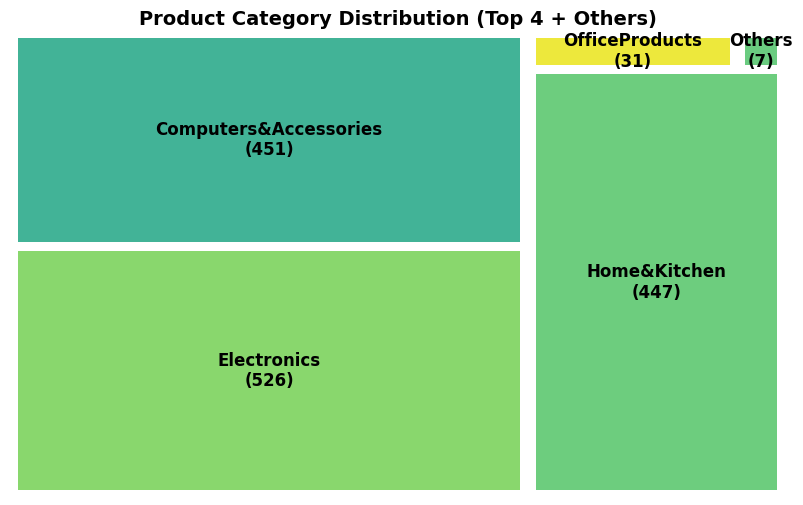

In [ ]:
labels = [f"{cat}\n({count})" for cat, count in treemap_data.items()]
plt.figure(figsize=(10,6))

squarify.plot(
    sizes = treemap_data.values,
    label = labels,
    alpha = 0.85,
    text_kwargs={'fontsize':12, 'weight':'bold'},
    pad=True
)

plt.title("Product Category Distribution (Top 4 + Others)", fontsize=14, weight='bold')
plt.axis('off')
plt.show()

### 3.2 Rating Distribution

In [ ]:
df['rating'].value_counts()

,count
rating,
4.1,244
4.3,230
4.2,228
4.0,181
3.9,123
4.4,123
3.8,86
4.5,75
3.7,42


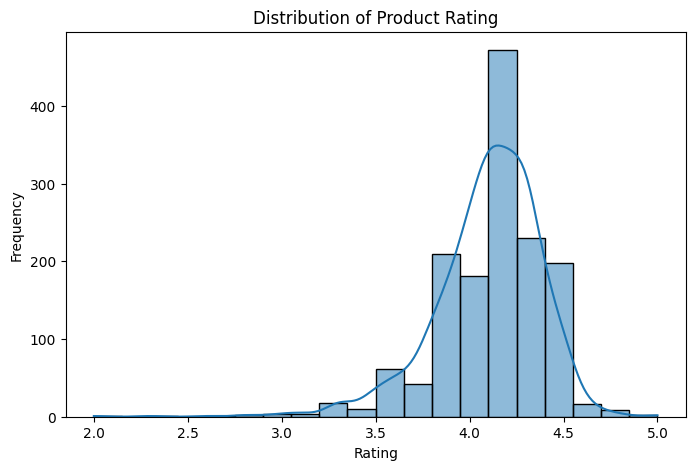

In [ ]:
# Plot Histogram
plt.figure(figsize=(8,5))
sns.histplot(df['rating'], kde=True, bins=20)
plt.title('Distribution of Product Rating')
plt.xlabel('Rating')
plt.ylabel('Frequency')
plt.show()

- Categories with fewer than 30 reviews were excluded to avoid misleading results caused by small-sample bias and ensure more reliable statistical insights

## 4.Sentiment Analysis

### 4.1 Label CSAT Flag

In [ ]:
df['csat_flag'] = (df['rating'] >=4).astype(int)

In [ ]:
# Calculate Overall CSAT score
csat_score = df['csat_flag'].mean()*100
print(f"Overall CSAT Score: {csat_score:.2f}%")

Overall CSAT Score: 75.85%


### 4.2 CSAT score per category

In [ ]:
csat_by_category = df.groupby('main_category')['csat_flag'].mean()*100
csat_by_category.sort_values(ascending=False)

,csat_flag
main_category,
Health&PersonalCare,100.000000
OfficeProducts,100.000000
Toys&Games,100.000000
HomeImprovement,100.000000
Computers&Accessories,83.592018
Electronics,74.714829
Home&Kitchen,67.785235
MusicalInstruments,50.000000
Car&Motorbike,0.000000


### 4.3 Exclude Dataset with Small Records

In [ ]:
valid_cats = df['main_category'].value_counts()[df['main_category'].value_counts() >= 30].index
df_clean = df[df['main_category'].isin(valid_cats)]

### 4.4 Clean review text

In [ ]:
import re
import string
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import nltk
nltk.download('stopwords')
nltk.download('wordnet')

stop = set(stopwords.words('english'))
lemm = WordNetLemmatizer()

def clean_text(text):
  text = text.lower() #lowercase
  text = re.sub(r'http\S+|www\S+|https\S+', '', text) # remove links
  text = text.encode('ascii','ignore').decode() # remove emoji
  text = text.translate(str.maketrans('', '', string.punctuation)) # remove punctuation
  text = ' '.join(lemm.lemmatize(w) for w in text.split() if w not in stop) # remove stopwords
  return text
df_clean['clean_text'] = df_clean['review_text'].apply(clean_text)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
/tmp/ipython-input-3068930068.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['clean_text'] = df_clean['review_text'].apply(clean_text)


In [ ]:
from nltk.sentiment.vader import SentimentIntensityAnalyzer

sid = SentimentIntensityAnalyzer()
df_clean['sentiment_score'] = df_clean['clean_text'].apply(lambda x: sid.polarity_scores(x)['compound'])
df_clean.head()

/tmp/ipython-input-2991982240.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['sentiment_score'] = df_clean['clean_text'].apply(lambda x: sid.polarity_scores(x)['compound'])


,product_id,product_name,category,discounted_price,actual_price,discount_percentage,rating,rating_count,about_product,review_text,main_category,csat_flag,clean_text,sentiment_score
0,B07JW9H4J1,Wayona Nylon Braided USB to Lightning Fast Cha...,Computers&Accessories|Accessories&Peripherals|...,399.0,1099.0,64%,4.2,24269,High Compatibility : Compatible With iPhone 12...,"Satisfied,Charging is really fast,Value for mo...",Computers&Accessories,1,satisfiedcharging really fastvalue moneyproduc...,0.9531
1,B098NS6PVG,Ambrane Unbreakable 60W / 3A Fast Charging 1.5...,Computers&Accessories|Accessories&Peripherals|...,199.0,349.0,43%,4.0,43994,"Compatible with all Type C enabled devices, be...","A Good Braided Cable for Your Type C Device,Go...",Computers&Accessories,1,good braided cable type c devicegood quality p...,0.9796
2,B096MSW6CT,Sounce Fast Phone Charging Cable & Data Sync U...,Computers&Accessories|Accessories&Peripherals|...,199.0,1899.0,90%,3.9,7928,【 Fast Charger& Data Sync】-With built-in safet...,"Good speed for earlier versions,Good Product,W...",Computers&Accessories,0,good speed earlier versionsgood productworking...,0.9335
3,B08HDJ86NZ,boAt Deuce USB 300 2 in 1 Type-C & Micro USB S...,Computers&Accessories|Accessories&Peripherals|...,329.0,699.0,53%,4.2,94363,The boAt Deuce USB 300 2 in 1 cable is compati...,"Good product,Good one,Nice,Really nice product...",Computers&Accessories,1,good productgood onenicereally nice productver...,0.9766
4,B08CF3B7N1,Portronics Konnect L 1.2M Fast Charging 3A 8 P...,Computers&Accessories|Accessories&Peripherals|...,154.0,399.0,61%,4.2,16905,[CHARGE & SYNC FUNCTION]- This cable comes wit...,"As good as original,Decent,Good one for second...",Computers&Accessories,1,good originaldecentgood one secondary usebest ...,0.9938


In [ ]:
def label_sentiment(score):
  if score >= 0.05:
    return 'positive'
  elif score <= -0.05:
    return 'negative'
  else:
    return "neutral"

df_clean['sentiment_label'] = df_clean['sentiment_score'].apply(label_sentiment)

/tmp/ipython-input-2811426677.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['sentiment_label'] = df_clean['sentiment_score'].apply(label_sentiment)


In [ ]:
df_clean['sentiment_label'].value_counts()

,count
sentiment_label,
positive,1425
negative,29
neutral,1


### 4.5 Sentiment Distribution

In [ ]:
df_clean['sentiment_label'].value_counts(normalize=True)*100

,proportion
sentiment_label,
positive,97.938144
negative,1.993127
neutral,0.068729


### 4.6 Sentiment per Category

In [ ]:
sent_cat = (
    df_clean.groupby(['main_category','sentiment_label'])
    .size()
    .groupby(level=0)
    .apply(lambda x: x / x.sum() * 100)
    .unstack()
)

sent_cat

,sentiment_label,negative,neutral,positive
main_category,main_category,,,
Computers&Accessories,Computers&Accessories,0.886918,NaN,99.113082
Electronics,Electronics,2.091255,NaN,97.908745
Home&Kitchen,Home&Kitchen,2.908277,0.223714,96.868009
OfficeProducts,OfficeProducts,3.225806,NaN,96.774194


### 4.7 Keyword Mining (Negative Review)

In [ ]:
negative = df_clean[df_clean['sentiment_label']=='negative']
negative.shape

(29, 15)

### 4.8 Extract Frequent Complaint words

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer
voc_stopwords = [
    'product','use','using','buy','got','one','day','come','room',
    'tv','money','good','another','fine','handle','heater','ok','overall',
    'provider','stand','time','unit'
]
cv = CountVectorizer(max_features=50, ngram_range=(1,2), stop_words = voc_stopwords)
neg_matrix = cv.fit_transform(negative['clean_text'])

keywords = pd.DataFrame(
    neg_matrix.sum(axis=0).A1,
    index=cv.get_feature_names_out(),
    columns=['count']
)

keywords.sort_values(by='count', ascending=False)


,count
bad,25
working,19
quality,18
battery,18
service,14
poor,14
low,13
dont,9
charge,9
home,8


In [ ]:
# Filtered Irrelevant words
selected_words = [
    'bad','working','quality','battery','service','poor','low','dont',
    'charge','broke'
]

In [ ]:
# Join all text
text = " ".join(negative['clean_text']).lower()
# Remove Punctuations and Symbol
text = re.sub(r'[^a-zA-Z\s]', '', text)
# Compress Multiple Space
text = re.sub(r'\s+', ' ', text).strip()

# Count words
from collections import Counter
word_counts = Counter(text.split()).most_common(200)

# Check wether broke exist or not
print(voc_df[voc_df['keyword'].str.contains('brok', na=False)])

# Convert to dataframe
voc_df = pd.DataFrame(word_counts, columns=['keyword','count'])

voc_filtered = voc_df[voc_df['keyword'].isin(selected_words)]
voc_filtered =  (
    voc_filtered.set_index('keyword')
    .reindex(selected_words, fill_value=0)
    .reset_index()
)

Empty DataFrame
Columns: [keyword, count]
Index: []


In [ ]:
voc_filtered

,keyword,count
0,bad,25
1,working,19
2,quality,18
3,battery,18
4,service,14
5,poor,14
6,low,13
7,dont,9
8,charge,9
9,broke,4


In [ ]:
voc_filtered.to_csv('voc_negative_top10_filtered.csv', index=False)

### 4.9 Topic Modeling LDA (Latent Dirichlet Allocation)

In [ ]:
# Import gensim, a library for topic modeling and natural language processing
import gensim
# simple preprocess: tokenizes and cleans text by lowercasing and removing punctuation
from gensim.utils import simple_preprocess
# Dictionary: creates a mapping of unique tokens to integer IDs for LDA model input
from gensim.corpora.dictionary import Dictionary

In [ ]:
from nltk.corpus import stopwords
nltk.download('stopwords')
stop_words = stopwords.words('english')

df_clean['tokens'] = df_clean['clean_text'].apply(
    lambda x: [word for word in simple_preprocess(x) if word not in stop_words]
)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
/tmp/ipython-input-707914434.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['tokens'] = df_clean['clean_text'].apply(


In [ ]:
dictionary = Dictionary(df_clean['tokens'])
corpus = [dictionary.doc2bow(text) for text in df_clean['tokens']]

In [ ]:
lda_model = gensim.models.LdaModel(
    corpus=corpus,
    id2word=dictionary,
    num_topics=2,
    passes=10,
    random_state=42
)

topics = lda_model.print_topics()
topics

[(0,
  '0.020*"good" + 0.016*"product" + 0.010*"quality" + 0.007*"tv" + 0.007*"use" + 0.006*"one" + 0.006*"price" + 0.005*"cable" + 0.005*"like" + 0.005*"also"'),
 (1,
  '0.028*"good" + 0.018*"product" + 0.011*"quality" + 0.008*"cable" + 0.008*"phone" + 0.007*"use" + 0.007*"charging" + 0.007*"price" + 0.006*"one" + 0.006*"like"')]

In [ ]:
for idx, topic in lda_model.show_topics(formatted=False, num_topics=2, num_words=10):
    print(f"\nTopic {idx+1}:")
    words = [word for word, prob in topic]
    print(", ".join(words))


Topic 1:
good, product, quality, tv, use, one, price, cable, like, also

Topic 2:
good, product, quality, cable, phone, use, charging, price, one, like


In [ ]:
lda_topics = []
for idx, topic in lda_model.show_topics(formatted=False, num_topics=2, num_words=10):
    words = ", ".join([word for word, prob in topic])
    lda_topics.append([f"Topic {idx+1}", words])

import pandas as pd
df_lda = pd.DataFrame(lda_topics, columns=["Topic", "Keywords"])
df_lda.to_csv("lda_topics.csv", index=False)
df_lda

,Topic,Keywords
0,Topic 1,"good, product, quality, tv, use, one, price, c..."
1,Topic 2,"good, product, quality, cable, phone, use, cha..."


In [ ]:
from google.colab import files
files.download("lda_topics.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 5.Insights

### 5.1 Rating Distribution

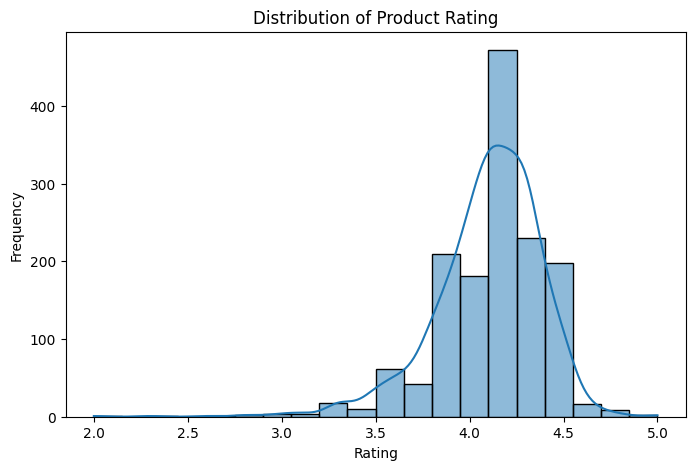

In [ ]:
# Plot Histogram
plt.figure(figsize=(8,5))
sns.histplot(df['rating'], kde=True, bins=20)
plt.title('Distribution of Product Rating')
plt.xlabel('Rating')
plt.ylabel('Frequency')
plt.show()

### 5.2 Top 5 Product Main Category Distribution

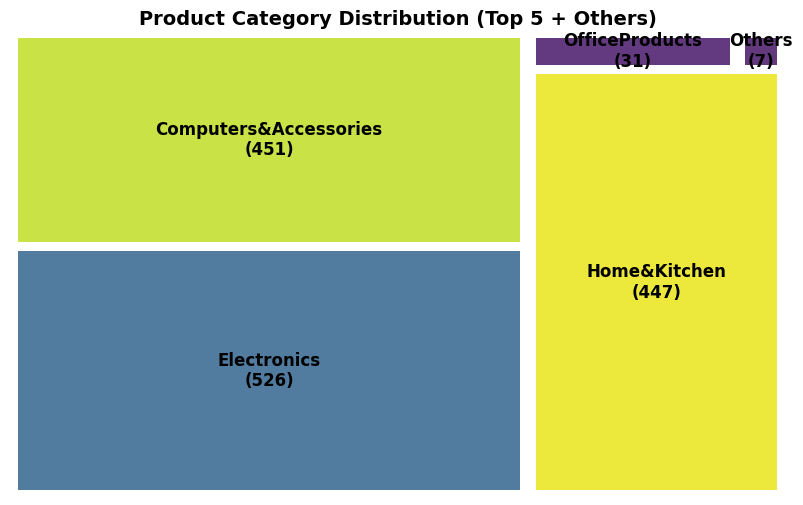

In [ ]:
top_n = 4
top_cats = df['main_category'].value_counts().head(top_n)

df['cat_clean'] = df['main_category'].apply(
    lambda x: x if x in top_cats.index else 'Others'
)

treemap_data = df['cat_clean'].value_counts()

# Build labels with category and count
labels = [f"{cat}\n({count})" for cat, count in treemap_data.items()]

plt.figure(figsize=(10,6))
squarify.plot(
    sizes=treemap_data.values,
    label=labels,
    alpha=0.85,
    text_kwargs={'fontsize':12, 'weight':'bold'},
    pad=True
)

plt.title("Product Category Distribution (Top 5 + Others)", fontsize=14, weight='bold')
plt.axis('off')
plt.show()

### 5.3 Count of Reviews per Category

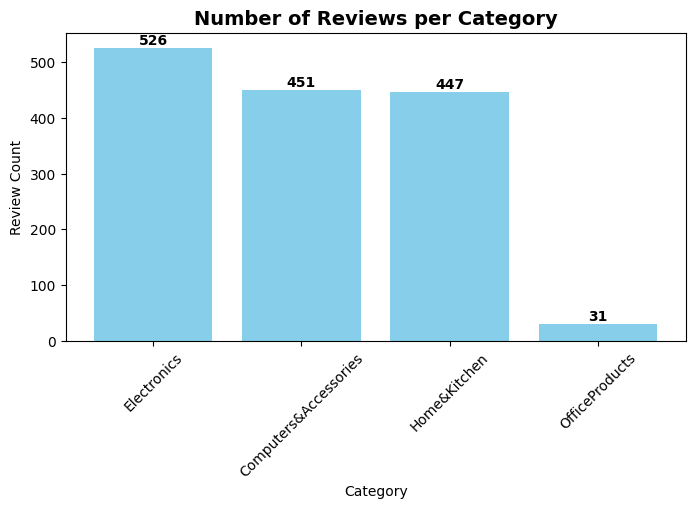

In [ ]:
counts = df_clean['main_category'].value_counts()

plt.figure(figsize=(8,4))
bars = plt.bar(counts.index, counts.values, color='skyblue')

plt.title("Number of Reviews per Category", fontsize=14, weight='bold')
plt.ylabel("Review Count")
plt.xlabel("Category")
plt.xticks(rotation=45)

# Add value labels at the top center of each bar
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,  # x position (center)
        height,                           # y position
        f'{int(height)}',                 # label text
        ha='center', va='bottom', fontsize=10, fontweight='bold'
    )

plt.show()

### 5.4 CSAT Score per Category

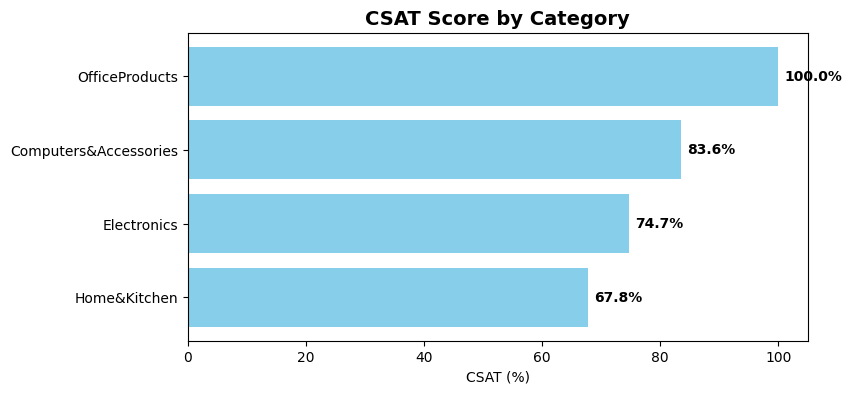

In [ ]:
csat_scores = df_clean.groupby('main_category')['csat_flag'].mean().sort_values() * 100

plt.figure(figsize=(8,4))
bars = plt.barh(csat_scores.index, csat_scores.values, color='skyblue')

plt.title("CSAT Score by Category", fontsize=14, weight='bold')
plt.xlabel("CSAT (%)")

# Add value labels
for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 1,                         # x: slightly after bar end
        bar.get_y() + bar.get_height()/2, # y: center of bar
        f'{width:.1f}%',                  # label format
        va='center', fontsize=10, fontweight='bold'
    )

plt.xlim(0, 105)  # give space for label
plt.show()

### 5.5 Sentiment Composition

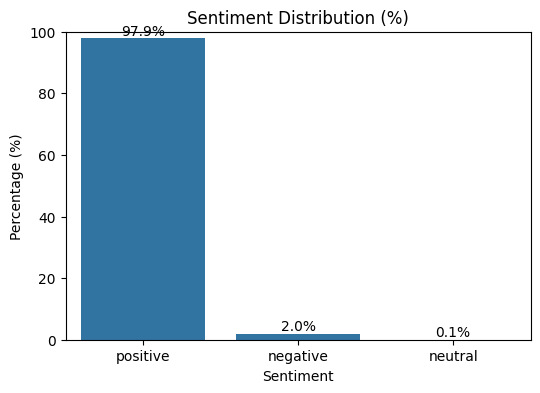

In [ ]:
sent_counts = df_clean['sentiment_label'].value_counts(normalize=True) * 100

plt.figure(figsize=(6,4))
sns.barplot(x=sent_counts.index, y=sent_counts.values)
plt.title("Sentiment Distribution (%)")
plt.ylabel("Percentage (%)")
plt.xlabel("Sentiment")
plt.ylim(0,100)

# Display value labels
for i, v in enumerate(sent_counts.values):
    plt.text(i, v + 1, f"{v:.1f}%", ha='center')

plt.show()

### 5.6 Wordcloud Positive Reviews

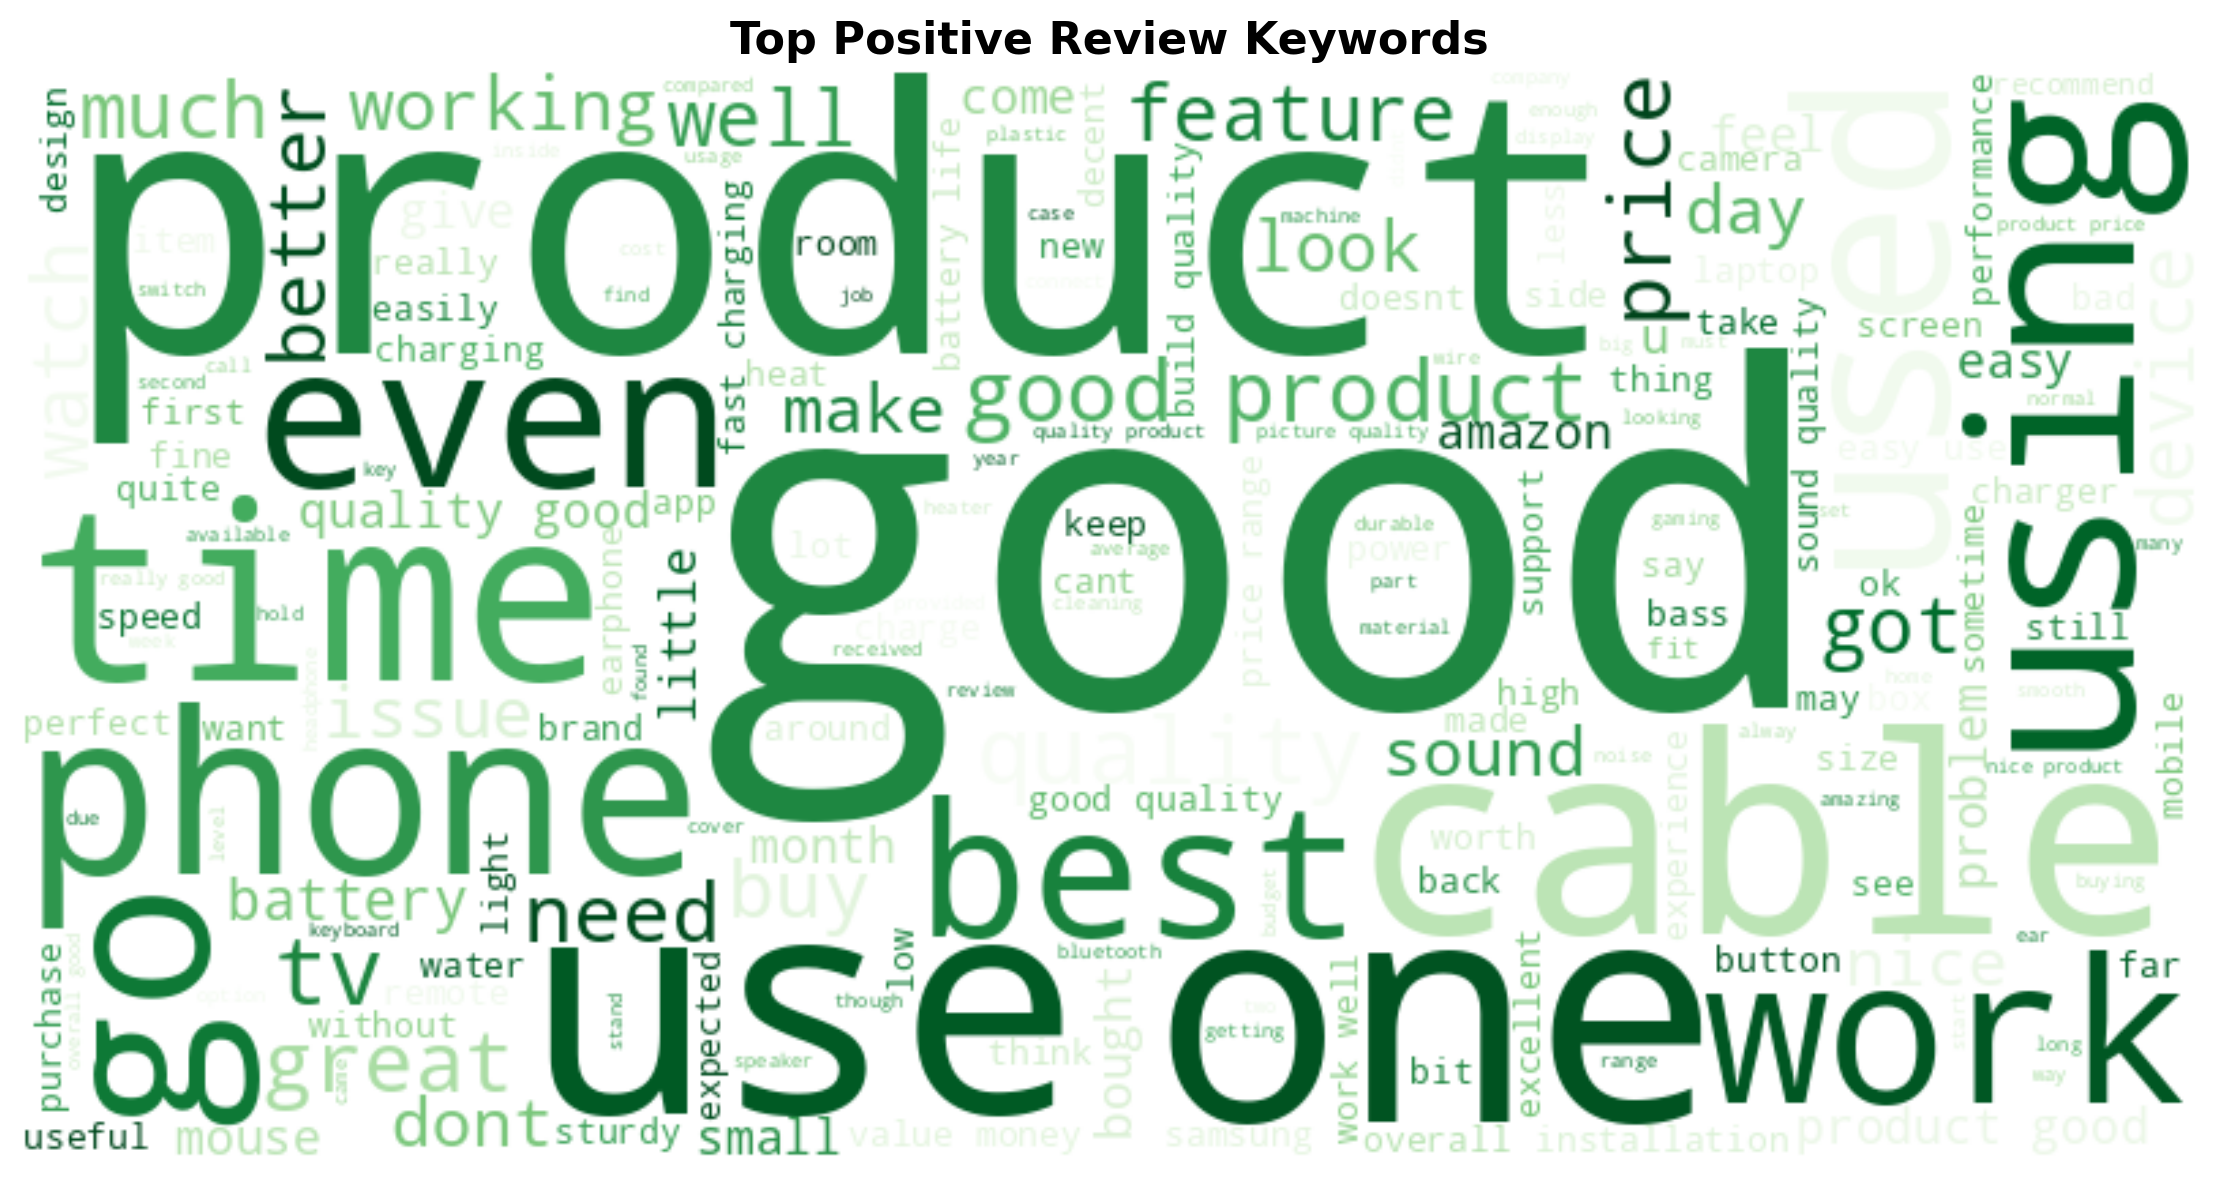

In [ ]:
positive_text = " ".join(df_clean[df_clean['sentiment_label']=='positive']['clean_text'])

wordcloud_pos = WordCloud(
    width=800,
    height=400,
    background_color='white',
    colormap='Greens'
).generate(positive_text)

plt.figure(figsize=(12,6), dpi=200)
plt.imshow(wordcloud_pos, interpolation='bilinear')
plt.axis('off')
plt.title("Top Positive Review Keywords", fontsize=16, weight='bold')
plt.tight_layout()
plt.savefig("positive_wordcloud.png", dpi=300, bbox_inches='tight')
plt.show()

### 5.7 Wordcloud Negative Reviews

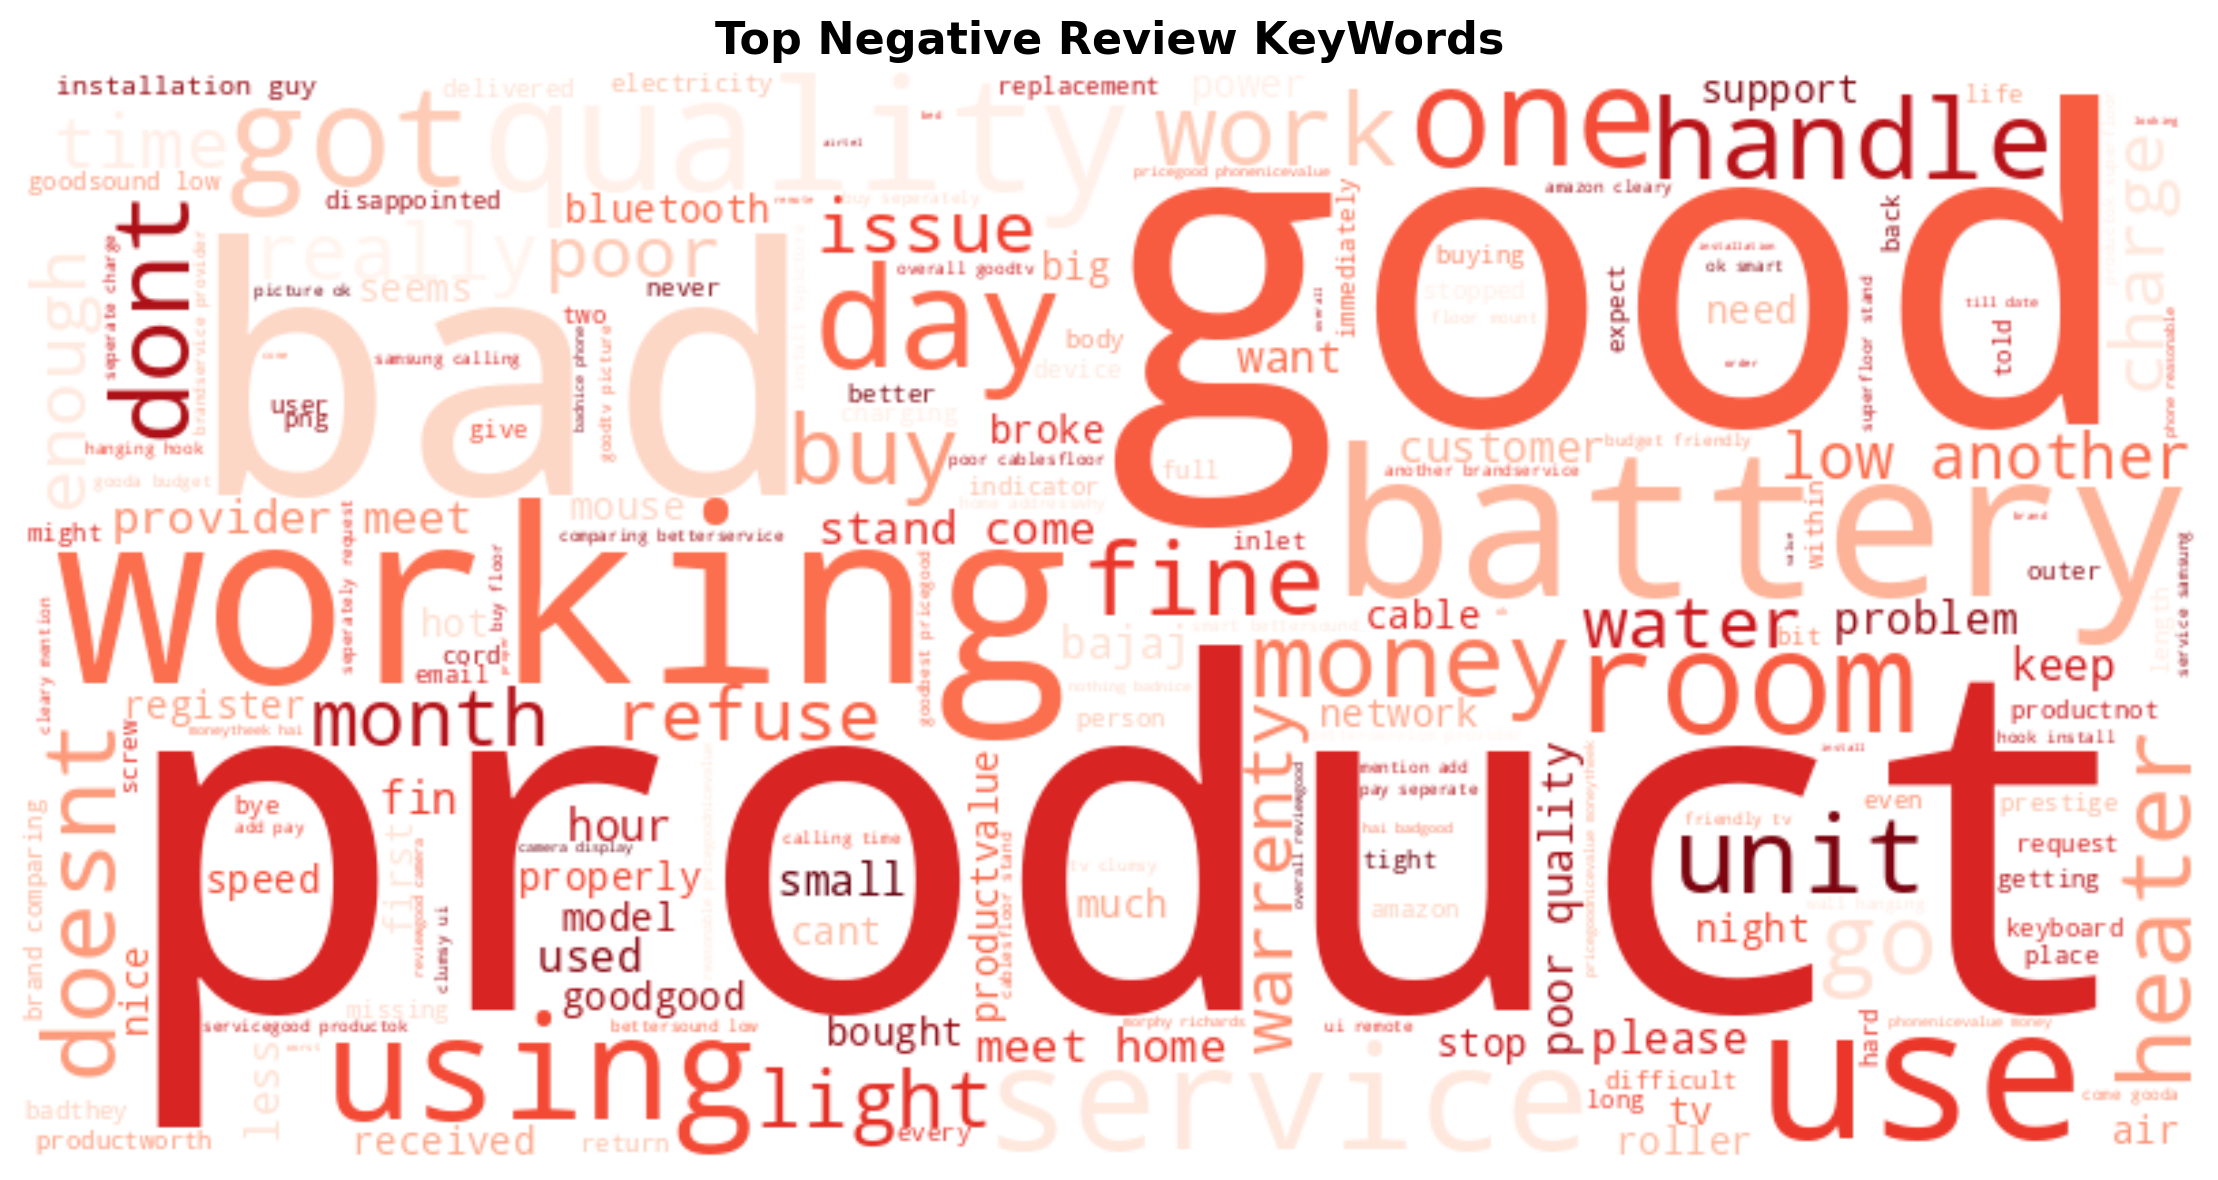

In [ ]:
negative_text = " ".join(df_clean[df_clean['sentiment_label']=='negative']['clean_text'])

wordcloud_neg = WordCloud(
    width=800,
    height=400,
    background_color='white',
    colormap='Reds'
).generate(negative_text)

plt.figure(figsize=(12,6), dpi=200)
plt.imshow(wordcloud_neg, interpolation='bilinear')
plt.axis('off')
plt.title("Top Negative Review KeyWords", fontsize=16, weight='bold')
plt.tight_layout()
plt.savefig("negative_wordcloud.png", dpi=300, bbox_inches='tight')
plt.show()

## 6. Hypothesis Testing

###6.1 Correlation between price and rating

In [ ]:
df_clean[['actual_price', 'discounted_price', 'rating']].corr(method='pearson')

,actual_price,discounted_price,rating
actual_price,1.000000,0.961888,0.122732
discounted_price,0.961888,1.000000,0.121385
rating,0.122732,0.121385,1.000000


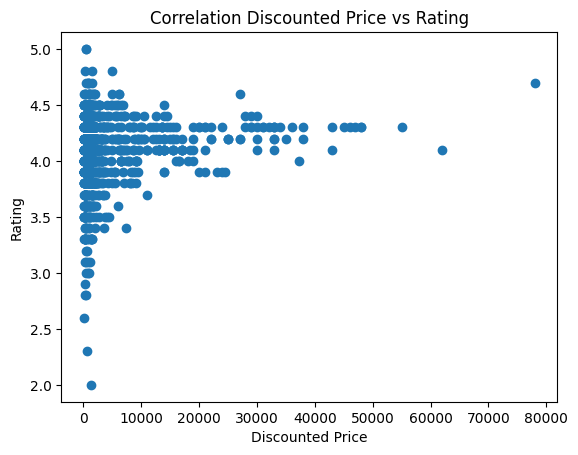

In [ ]:
import matplotlib.pyplot as plt

plt.scatter(df_clean['discounted_price'], df_clean['rating'])
plt.xlabel('Discounted Price')
plt.ylabel('Rating')
plt.title('Correlation Discounted Price vs Rating')
plt.show()

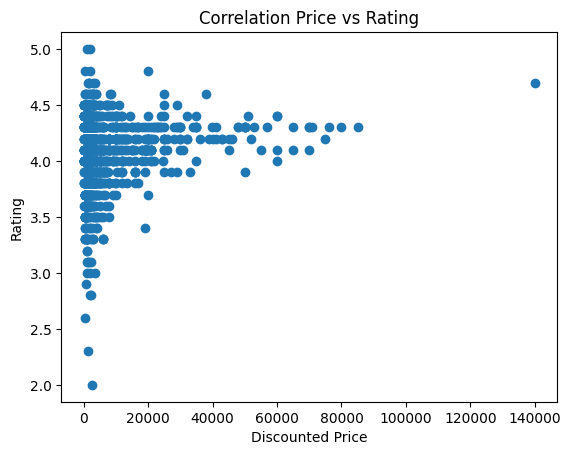

In [ ]:
plt.scatter(df_clean['actual_price'], df_clean['rating'])
plt.xlabel('Discounted Price')
plt.ylabel('Rating')
plt.title('Correlation Price vs Rating')
plt.show()

In [ ]:
# Check the discounted_price =='0' what is the actual_price
df_clean[df_clean['discounted_price'] == 0][['product_name', 'discounted_price', 'actual_price']]

,product_name,discounted_price,actual_price


In [ ]:
df_clean['discounted_price'].value_counts()

,count
discounted_price,
199.0,52
299.0,46
399.0,36
499.0,34
349.0,31
...,...
1928.0,1
5865.0,1
85.0,1


In [ ]:
from scipy.stats import pearsonr, spearmanr

pearson_corr, p_pearson = pearsonr(df_clean['discounted_price'], df_clean['rating'])
spearman_corr, p_spearman = spearmanr(df_clean['discounted_price'], df_clean['rating'])
print(pearson_corr, spearman_corr)

0.12138466315495372 0.08275911050008837


In [ ]:
print(f"Pearson r = {pearson_corr:.4f}, p-value = {p_pearson:.6f}")
print(f"Spearman ρ = {spearman_corr:.4f}, p-value = {p_spearman:.6f}")

Pearson r = 0.1214, p-value = 0.000003
Spearman ρ = 0.0828, p-value = 0.001580


In [ ]:
# Calculate Pearson Correlation
pearson_corr, p_value = pearsonr(df_clean['discounted_price'], df_clean['rating'])

print("=== Pearson Correlation Test ===")
print(f"Coef Correlation (r): {pearson_corr:.4f}")
print(f"P-value: {p_value:.6f}")

# Simple Interpretation
if p_value < 0.05:
    print("\n💡 The result is statistically significant (p < 0.05).")
    if pearson_corr > 0:
        print("➡️  There is a positive relationship: as the price increases, the rating tends to increase.")
    elif pearson_corr < 0:
        print("➡️  There is a negative relationship: as the price increases, the rating tends to decrease.")
    else:
        print("➡️  There is no meaningful linear relationship.")
else:
    print("\n⚙️  Not Significant (p ≥ 0.05).")
    print("➡️  There is no strong evidence that price affects rating.")

=== Pearson Correlation Test ===
Coef Correlation (r): 0.1214
P-value: 0.000003

💡 The result is statistically significant (p < 0.05).
➡️  There is a positive relationship: as the price increases, the rating tends to increase.


In [ ]:
# Calculate Pearson Correlation
pearson_corr, p_value = pearsonr(df_clean['actual_price'], df_clean['rating'])

print("=== Pearson Correlation Test ===")
print(f"Coef Correlation (r): {pearson_corr:.4f}")
print(f"P-value: {p_value:.6f}")

# Simple Interpretation
if p_value < 0.05:
    print("\n💡 The result is statistically significant (p < 0.05).")
    if pearson_corr > 0:
        print("➡️  There is a positive relationship: as the price increases, the rating tends to increase.")
    elif pearson_corr < 0:
        print("➡️  There is a negative relationship: as the price increases, the rating tends to decrease.")
    else:
        print("➡️  There is no meaningful linear relationship.")
else:
    print("\n⚙️  Not Significant (p ≥ 0.05).")
    print("➡️  There is no strong evidence that price affects rating.")

=== Pearson Correlation Test ===
Coef Correlation (r): 0.1227
P-value: 0.000003

💡 The result is statistically significant (p < 0.05).
➡️  There is a positive relationship: as the price increases, the rating tends to increase.


In [ ]:
# Calculate Pearson
pearson_r_disc, pearson_p_disc = pearsonr(df_clean['discounted_price'], df_clean['rating'])
pearson_r_act, pearson_p_act = pearsonr(df_clean['actual_price'], df_clean['rating'])

# Calculate Spearman
spearman_r_disc, spearman_p_disc = spearmanr(df_clean['discounted_price'], df_clean['rating'])
spearman_r_act, spearman_p_act = spearmanr(df_clean['actual_price'], df_clean['rating'])

In [ ]:
# Create result table
results = pd.DataFrame({
    'Variable': ['Discounted Price', 'Actual Price'],
    'Pearson Corr': [pearson_r_disc, pearson_r_act],
    'Pearson P-Value': [pearson_p_disc, pearson_p_act],
    'Spearman Corr': [spearman_r_disc, spearman_r_act],
    'Spearman P-Value': [spearman_p_disc, spearman_p_act]
})

# Format clear numbber
results = results.round(5)

# Show table result
print("=== Result Correlation Pearson & Spearman ===")
display(results)

=== Result Correlation Pearson & Spearman ===


,Variable,Pearson Corr,Pearson P-Value,Spearman Corr,Spearman P-Value
0,Discounted Price,0.12138,0.0,0.08276,0.00158
1,Actual Price,0.12273,0.0,0.03575,0.17285


In [ ]:
results['Pearson P-Value'] = results['Pearson P-Value'].apply(lambda x: f"{x:.8f}")
results['Spearman P-Value'] = results['Spearman P-Value'].apply(lambda x: f"{x:.8f}")

display(results)

,Variable,Pearson Corr,Pearson P-Value,Spearman Corr,Spearman P-Value
0,Discounted Price,0.12138,0.00000000,0.08276,0.00158000
1,Actual Price,0.12273,0.00000000,0.03575,0.17285000


- Eventhough the p-value shows significant result, the correlation is very weak, it means there's no such high impact in real world between more expensive price with higher ratings.

In [ ]:
df_clean

,product_id,product_name,category,discounted_price,actual_price,discount_percentage,rating,rating_count,about_product,review_text,main_category,csat_flag,clean_text,sentiment_score,sentiment_label,tokens
0,B07JW9H4J1,Wayona Nylon Braided USB to Lightning Fast Cha...,Computers&Accessories|Accessories&Peripherals|...,399.0,1099.0,64%,4.2,24269,High Compatibility : Compatible With iPhone 12...,"Satisfied,Charging is really fast,Value for mo...",Computers&Accessories,1,satisfiedcharging really fastvalue moneyproduc...,0.9531,positive,"[really, fastvalue, moneyproduct, reviewgood, ..."
1,B098NS6PVG,Ambrane Unbreakable 60W / 3A Fast Charging 1.5...,Computers&Accessories|Accessories&Peripherals|...,199.0,349.0,43%,4.0,43994,"Compatible with all Type C enabled devices, be...","A Good Braided Cable for Your Type C Device,Go...",Computers&Accessories,1,good braided cable type c devicegood quality p...,0.9796,positive,"[good, braided, cable, type, devicegood, quali..."
2,B096MSW6CT,Sounce Fast Phone Charging Cable & Data Sync U...,Computers&Accessories|Accessories&Peripherals|...,199.0,1899.0,90%,3.9,7928,【 Fast Charger& Data Sync】-With built-in safet...,"Good speed for earlier versions,Good Product,W...",Computers&Accessories,0,good speed earlier versionsgood productworking...,0.9335,positive,"[good, speed, earlier, versionsgood, productwo..."
3,B08HDJ86NZ,boAt Deuce USB 300 2 in 1 Type-C & Micro USB S...,Computers&Accessories|Accessories&Peripherals|...,329.0,699.0,53%,4.2,94363,The boAt Deuce USB 300 2 in 1 cable is compati...,"Good product,Good one,Nice,Really nice product...",Computers&Accessories,1,good productgood onenicereally nice productver...,0.9766,positive,"[good, productgood, onenicereally, nice, produ..."
4,B08CF3B7N1,Portronics Konnect L 1.2M Fast Charging 3A 8 P...,Computers&Accessories|Accessories&Peripherals|...,154.0,399.0,61%,4.2,16905,[CHARGE & SYNC FUNCTION]- This cable comes wit...,"As good as original,Decent,Good one for second...",Computers&Accessories,1,good originaldecentgood one secondary usebest ...,0.9938,positive,"[good, one, secondary, usebest, product, mind,..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1460,B08L7J3T31,Noir Aqua - 5pcs PP Spun Filter + 1 Spanner | ...,Home&Kitchen|Kitchen&HomeAppliances|WaterPurif...,379.0,919.0,59%,4.0,1090,SUPREME QUALITY 90 GRAM 3 LAYER THIK PP SPUN F...,"Received the product without spanner,Excellent...",Home&Kitchen,1,received product without spannerexcellent prod...,0.9655,positive,"[received, product, without, productgreat, yet..."
1461,B01M6453MB,Prestige Delight PRWO Electric Rice Cooker (1 ...,Home&Kitchen|Kitchen&HomeAppliances|SmallKitch...,2280.0,3045.0,25%,4.1,4118,"230 Volts, 400 watts, 1 Year","ok,everything was good couldn't return bcoz I ...",Home&Kitchen,1,okeverything good couldnt return bcoz needed e...,0.6331,positive,"[okeverything, good, couldnt, return, bcoz, ne..."
1462,B009P2LIL4,Bajaj Majesty RX10 2000 Watts Heat Convector R...,"Home&Kitchen|Heating,Cooling&AirQuality|RoomHe...",2219.0,3080.0,28%,3.6,468,International design and styling|Two heat sett...,"very good,Work but front melt after 2 month,Go...",Home&Kitchen,0,goodwork front melt 2 monthgood oneit durabler...,0.9274,positive,"[goodwork, front, melt, monthgood, oneit, prod..."
1463,B00J5DYCCA,Havells Ventil Air DSP 230mm Exhaust Fan (Pist...,"Home&Kitchen|Heating,Cooling&AirQuality|Fans|E...",1399.0,1890.0,26%,4.0,8031,Fan sweep area: 230 MM ; Noise level: (40 - 45...,"Fan Speed is slow,Good quality,Good product,go...",Home&Kitchen,1,fan speed slowgood qualitygood productgoodold ...,0.4939,positive,"[fan, speed, slowgood, qualitygood, productgoo..."


In [ ]:
df_clean.to_csv('Final Project DA Sentiment Analysis.csv', index=False)